# Does real brain wiring actually help? A connectome-constrained RL agent

**Data:** the *Drosophila* connectome from neuPrint (Janelia)
**Question:** if you build an RL agent whose network *is* the fly's real wiring diagram,
does that wiring earn its keep — and does the trained agent organise itself the way a real fly brain does?

This notebook runs four things end to end:

1. **Build** a policy network whose neurons and connections are the real fly connectome.
   Synapse counts set the initial weights; predicted neurotransmitters set each connection's
   sign (excitatory / inhibitory). Observations are injected at real **sensory** neurons and
   actions are read out of real **descending** neurons — the ones that actually drive
   locomotion in a fly.
2. **Train** it with PPO on a foraging + threat-avoidance task, then train a **rewired control**:
   same neuron count, same synapse count, same degree distribution — wiring shuffled. This is
   the comparison that makes the whole thing a real experiment rather than a demo.
3. **Virtual lesions**: silence each neuropil in turn, measure what breaks, against a
   size-matched random-neuron control.
4. **Functional specialisation**: check which neuropils are more active during threat episodes
   vs foraging episodes — without ever having told the network what any region is for.

---

### Before you run

- You need a **free neuPrint account and API token** — see the token cell below.
- `SMOKE_TEST = True` by default, so your first pass finishes in a few minutes and proves the
  whole pipeline works. Flip it to `False` for the real run (roughly 1.5–2.5 h on an M-series Mac).
- The connectome download is cached to disk, so you only pay for it once.

### A note on what's already been checked

The environment is tuned so the task is genuinely learnable — verified against hand-coded
reference controllers (a random walker scores about **−8** return; a hand-coded chemotaxis
controller about **+7**). Cell 9 re-runs that check on your machine, so if training later goes
nowhere you can tell immediately whether the task or the network is at fault.


## 1. Setup

In [20]:
import sys, subprocess

def ensure(pkg, imp=None):
    try:
        __import__(imp or pkg)
    except ImportError:
        print(f"installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for p, i in [("torch", "torch"), ("numpy", "numpy"), ("pandas", "pandas"),
             ("matplotlib", "matplotlib"), ("neuprint-python", "neuprint")]:
    ensure(p, i)

import os, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore")

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print("python", sys.version.split()[0], "| torch", torch.__version__, "| device:", DEVICE)


python 3.11.8 | torch 2.7.0 | device: mps


## 2. Configuration

Everything you'd want to change lives here.

`SMOKE_TEST = True` uses a small slice of the connectome and a short training run so you can
confirm the pipeline works before committing to the full thing.


In [21]:
SMOKE_TEST = True          # <-- flip to False for the real run

# ---- connectome source -------------------------------------------------
NEUPRINT_SERVER = "https://neuprint.janelia.org"
DATASET         = "male-cns:v1.0"   # or "hemibrain:v1.2.1" (smaller, older, no neurotransmitters)
MIN_SYNAPSES    = 5                 # drop connections weaker than this (standard practice)

# ---- size caps (memory) ------------------------------------------------
MAX_NEURONS = 6_000 if SMOKE_TEST else 20_000
MAX_EDGES   = 150_000 if SMOKE_TEST else 600_000

# ---- network -----------------------------------------------------------
TICKS = 1          # recurrent updates per environment step
GAIN  = 1.5        # global scale on recurrent input
USE_NT_SIGNS = True  # acetylcholine -> excitatory, GABA/glutamate -> inhibitory

# ---- task (tuned so the task is actually learnable; see cell 9) ---------
ENV_CFG = dict(arena=16.0, n_food=10, odor_sigma=2.5, eat_radius=1.2,
               shaping=0.5, step_cost=0.002, catch_penalty=1.0, food_reward=1.0,
               threat_speed=0.14, catch_radius=1.0, max_speed=0.35, max_turn=0.35)

# ---- training ----------------------------------------------------------
BATCH_ENVS = 8   if SMOKE_TEST else 16
ROLLOUT_T  = 64  if SMOKE_TEST else 128
UPDATES    = 25  if SMOKE_TEST else 300
LR, MINIBATCH, PPO_EPOCHS = 1e-3, 128, 4
# Per-destination normalisation makes each biological weight tiny (~1/in-degree), so the
# per-synapse gains get a proportionally tiny gradient. They need their own, larger step
# size or they never move off 1.0 and result 4 is meaningless.
GAIN_LR_MULT = 20.0
EVAL_STEPS = 150 if SMOKE_TEST else 300
SEED = 0

CACHE_DIR = "connectome_cache"
OUT_DIR   = "results"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

torch.manual_seed(SEED); np.random.seed(SEED)
print(f"mode: {'SMOKE TEST' if SMOKE_TEST else 'FULL RUN'} | "
      f"<={MAX_NEURONS} neurons, <={MAX_EDGES} connections, {UPDATES} updates")


mode: SMOKE TEST | <=6000 neurons, <=150000 connections, 25 updates


## 3. neuPrint token

1. Go to **https://neuprint.janelia.org** and sign in with a Google account (free).
2. Click your avatar (top right) → **Account** → copy the **Auth Token**.
3. Paste it when prompted below. It is not saved to the notebook.

You can also set it once in your shell as `NEUPRINT_TOKEN` and skip the prompt.


In [22]:
from getpass import getpass

TOKEN = os.environ.get("NEUPRINT_TOKEN", "")  # export NEUPRINT_TOKEN=... before starting Jupyter
print("token loaded:", bool(TOKEN), "| length:", len(TOKEN))

token loaded: True | length: 64


## 4. Download the connectome (cached)

This pulls every traced neuron and every connection of at least `MIN_SYNAPSES` synapses,
then caches the result. Re-running is instant.

The first download on the full dataset can take several minutes.


In [23]:
# neuprint tries to use a widget progress bar that needs ipywidgets; swap it
# for the plain text version so the download doesn't depend on widget rendering.
import sys, types
import tqdm.std as _tqdm_std

_fake_notebook = types.ModuleType("tqdm.notebook")
_fake_notebook.tqdm = _tqdm_std.tqdm
_fake_notebook.trange = _tqdm_std.trange
sys.modules["tqdm.notebook"] = _fake_notebook

from neuprint import Client, fetch_adjacencies, NeuronCriteria as NC

cache_file = os.path.join(
    CACHE_DIR, f"{DATASET.replace(':', '_').replace('.', '_')}_w{MIN_SYNAPSES}.npz")

WANT_PROPS = ["type", "instance", "class", "subclass", "superclass",
              "predictedNt", "consensusNt", "somaSide"]


def download_connectome():
    client = Client(NEUPRINT_SERVER, dataset=DATASET, token=TOKEN)
    print("connected:", client.dataset)

    # discover which annotation columns this dataset actually has
    try:
        keys = client.fetch_custom("MATCH (n:Neuron) RETURN keys(n) AS k LIMIT 1")["k"][0]
    except Exception as e:
        print("  (could not probe properties:", e, ") -- using defaults")
        keys = ["type", "instance"]
    props = [p for p in WANT_PROPS if p in keys]
    print("  annotation columns available:", props)

    try:
        criteria = NC(status="Traced", cropped=False)
        neurons, conns = fetch_adjacencies(criteria, criteria,
                                           min_total_weight=MIN_SYNAPSES,
                                           properties=props, client=client)
    except Exception as e:
        print("  'Traced' criteria failed (", e, ") -- retrying without status filter")
        neurons, conns = fetch_adjacencies(NC(), NC(),
                                           min_total_weight=MIN_SYNAPSES,
                                           properties=props, client=client)
    print(f"  fetched {len(neurons)} neurons, {len(conns)} connection rows")
    return neurons, conns


if os.path.exists(cache_file):
    z = np.load(cache_file, allow_pickle=True)
    neurons = pd.DataFrame(z["neurons"].item())
    conns = pd.DataFrame(z["conns"].item())
    print("loaded from cache:", cache_file)
else:
    t0 = time.time()
    neurons, conns = download_connectome()
    np.savez_compressed(cache_file,
                        neurons=neurons.to_dict("list"),
                        conns=conns.to_dict("list"))
    print(f"downloaded in {time.time()-t0:.0f}s -> cached at {cache_file}")

print("neuron columns:", list(neurons.columns))
print("connection columns:", list(conns.columns))
neurons.head(3)


loaded from cache: connectome_cache/male-cns_v1_0_w5.npz
neuron columns: ['bodyId', 'type', 'instance', 'class', 'subclass', 'superclass', 'predictedNt', 'consensusNt']
connection columns: ['bodyId_pre', 'bodyId_post', 'roi', 'weight']


,bodyId,type,instance,class,subclass,superclass,predictedNt,consensusNt
0,10001,DNp01,DNp01(GF)_R,None,lt,descending_neuron,acetylcholine,acetylcholine
1,10002,OCG01d,OCG01d_L,None,None,visual_projection,acetylcholine,acetylcholine
2,10003,VCH,VCH_R,None,None,visual_centrifugal,gaba,gaba


## 5. Turn it into a graph

Three things happen here, and each is a modelling decision worth being able to defend:

- **Signs from neurotransmitters.** Acetylcholine → excitatory; GABA and glutamate → inhibitory
  (in *Drosophila*, glutamate is usually inhibitory via GluCl channels). If the dataset has no
  neurotransmitter predictions, everything defaults to excitatory and you get a warning.
- **Sensory in, descending out.** Observations are injected at annotated sensory neurons;
  actions are read from descending neurons, which are the real output pathway from the fly's
  brain to its body. If the dataset lacks those annotations, the code falls back to
  the most-connected input/output neurons and tells you so.
- **Neuropil per neuron** is assigned from where that neuron receives most of its input.


In [24]:
EXCITATORY = {"acetylcholine", "ach", "cholinergic"}
INHIBITORY = {"gaba", "gabaergic", "glutamate", "glutamatergic"}


def build_graph(neurons, conns):
    agg = (conns.groupby(["bodyId_pre", "bodyId_post"], as_index=False)["weight"]
                .sum())
    agg = agg[agg["weight"] >= MIN_SYNAPSES]
    agg = agg[agg["bodyId_pre"] != agg["bodyId_post"]]

    # keep the best-connected neurons if we're over the cap
    strength = (pd.concat([agg.groupby("bodyId_pre")["weight"].sum(),
                           agg.groupby("bodyId_post")["weight"].sum()])
                  .groupby(level=0).sum().sort_values(ascending=False))
    keep_ids = set(strength.index[:MAX_NEURONS])
    agg = agg[agg["bodyId_pre"].isin(keep_ids) & agg["bodyId_post"].isin(keep_ids)]

    if len(agg) > MAX_EDGES:
        agg = agg.nlargest(MAX_EDGES, "weight")

    ids = pd.Index(sorted(set(agg["bodyId_pre"]) | set(agg["bodyId_post"])))
    pos = pd.Series(np.arange(len(ids)), index=ids)
    src = pos[agg["bodyId_pre"].values].values
    dst = pos[agg["bodyId_post"].values].values
    weight = agg["weight"].values.astype(np.float32)

    meta = neurons.set_index("bodyId").reindex(ids)

    # ---- signs --------------------------------------------------------
    sign = np.ones(len(src), dtype=np.float32)
    nt_col = next((c for c in ["consensusNt", "predictedNt"] if c in meta.columns), None)
    if USE_NT_SIGNS and nt_col is not None:
        nt = meta[nt_col].astype(str).str.lower().fillna("")
        s = np.ones(len(ids), dtype=np.float32)
        s[nt.isin(INHIBITORY).values] = -1.0
        sign = s[src]
        n_inh = int((s < 0).sum())
        print(f"  neurotransmitters from '{nt_col}': {n_inh} inhibitory / {len(ids)} neurons "
              f"({100*n_inh/len(ids):.1f}%)")
    else:
        print("  !! no neurotransmitter predictions in this dataset -- all connections "
              "treated as excitatory")

    # ---- dominant neuropil from incoming synapses ---------------------
    if "roi" in conns.columns:
        cin = conns[conns["bodyId_post"].isin(ids)]
        top = (cin.groupby(["bodyId_post", "roi"])["weight"].sum()
                  .reset_index()
                  .sort_values("weight", ascending=False)
                  .drop_duplicates("bodyId_post")
                  .set_index("bodyId_post")["roi"])
        neuropil = top.reindex(ids).fillna("unknown").values.astype(str)
    else:
        neuropil = np.array(["unknown"] * len(ids))

    # ---- sensory / descending -----------------------------------------
    def col_match(cols, patterns):
        hit = np.zeros(len(ids), dtype=bool)
        for c in cols:
            if c in meta.columns:
                v = meta[c].astype(str).str.lower().fillna("")
                for p in patterns:
                    hit |= v.str.contains(p, regex=True, na=False).values
        return hit

    sens = col_match(["class", "superclass", "subclass"], [r"sensory", r"afferent"])
    if sens.sum() < 8:
        sens = col_match(["type", "instance"], [r"^orn", r"^hrn", r"^r[1-8]\b", r"photoreceptor"])
    if sens.sum() < 8:
        indeg = np.bincount(dst, minlength=len(ids))
        outdeg = np.bincount(src, minlength=len(ids))
        score = outdeg - indeg
        sens = np.zeros(len(ids), dtype=bool)
        sens[np.argsort(-score)[:128]] = True
        print("  !! no sensory annotations -- using the 128 most output-dominant neurons instead")

    dn = col_match(["class", "superclass", "subclass"], [r"descending"])
    if dn.sum() < 8:
        dn = col_match(["type", "instance"], [r"^dn[a-z]?\d", r"^dn"])
    if dn.sum() < 8:
        indeg = np.bincount(dst, minlength=len(ids))
        outdeg = np.bincount(src, minlength=len(ids))
        score = indeg - outdeg
        dn = np.zeros(len(ids), dtype=bool)
        dn[np.argsort(-score)[:128]] = True
        print("  !! no descending annotations -- using the 128 most input-dominant neurons instead")

    sens_idx = np.where(sens)[0]
    dn_idx = np.where(dn)[0]
    # a neuron can't be both the input port and the output port
    dn_idx = np.setdiff1d(dn_idx, sens_idx)

    return ConnectomeGraph(src, dst, weight, sign, neuropil, sens_idx, dn_idx, len(ids),
                           names=meta.get("type", pd.Series(index=ids)).values)


class ConnectomeGraph:
    def __init__(self, src, dst, weight, sign, neuropil, sensory_idx, dn_idx, n_nodes, names=None):
        self.src = np.asarray(src, dtype=np.int64)
        self.dst = np.asarray(dst, dtype=np.int64)
        self.weight = np.asarray(weight, dtype=np.float32)
        self.sign = np.asarray(sign, dtype=np.float32)
        self.neuropil = np.asarray(neuropil).astype(str)
        self.sensory_idx = np.asarray(sensory_idx, dtype=np.int64)
        self.dn_idx = np.asarray(dn_idx, dtype=np.int64)
        self.n_nodes = int(n_nodes)
        self.names = names

    @property
    def n_edges(self):
        return len(self.src)

    def normalized_base(self):
        '''Per-destination normalisation: every neuron's total input weight sums to ~1,
        which keeps the recurrent dynamics stable regardless of how hub-like a neuron is.'''
        w = np.log1p(self.weight)
        tot = np.zeros(self.n_nodes, dtype=np.float64)
        np.add.at(tot, self.dst, w)
        return (w / np.maximum(tot, 1e-6)[self.dst]).astype(np.float32)

    def summary(self):
        return (f"{self.n_nodes:,} neurons | {self.n_edges:,} connections | "
                f"{len(self.sensory_idx)} sensory-in | {len(self.dn_idx)} descending-out | "
                f"{len(set(self.neuropil.tolist()))} neuropils | "
                f"{100*(self.sign<0).mean():.1f}% inhibitory connections")


graph = build_graph(neurons, conns)
print("\n" + graph.summary())

mem_mb = ROLLOUT_T * BATCH_ENVS * graph.n_nodes * 4 / 1e6
print(f"rollout buffer will use ~{mem_mb:,.0f} MB "
      f"({ROLLOUT_T} steps x {BATCH_ENVS} envs x {graph.n_nodes:,} neurons)")
if mem_mb > 1500:
    print("  !! that's a lot -- lower MAX_NEURONS, ROLLOUT_T or BATCH_ENVS")


  neurotransmitters from 'consensusNt': 2904 inhibitory / 6000 neurons (48.4%)
  !! no sensory annotations -- using the 128 most output-dominant neurons instead

6,000 neurons | 150,000 connections | 128 sensory-in | 522 descending-out | 88 neuropils | 41.7% inhibitory connections
rollout buffer will use ~12 MB (64 steps x 8 envs x 6,000 neurons)


## 6. The rewired control

The comparison that turns this from a demo into an experiment.

We shuffle which neuron each connection lands on, while keeping every neuron's **out-degree**
exactly and the **in-degree distribution** as a whole. Same number of neurons, same number of
synapses, same synaptic strengths, same signs — only the *pattern* of who talks to whom is
destroyed. If the real connectome is no better than this, its wiring wasn't doing anything.


In [25]:
def rewire_configuration_model(graph, seed=0):
    rng = np.random.default_rng(seed)
    new_dst = graph.dst.copy()
    rng.shuffle(new_dst)
    keep = new_dst != graph.src           # drop accidental self-loops
    return ConnectomeGraph(graph.src[keep], new_dst[keep], graph.weight[keep],
                           graph.sign[keep], graph.neuropil, graph.sensory_idx,
                           graph.dn_idx, graph.n_nodes, graph.names)


graph_rewired = rewire_configuration_model(graph, seed=SEED + 1)
print("real:    ", graph.summary())
print("rewired: ", graph_rewired.summary())


real:     6,000 neurons | 150,000 connections | 128 sensory-in | 522 descending-out | 88 neuropils | 41.7% inhibitory connections
rewired:  6,000 neurons | 149,951 connections | 128 sensory-in | 522 descending-out | 88 neuropils | 41.7% inhibitory connections


## 7. The world

A 2-D arena. The fly has two odour sensors and two threat sensors, offset left and right of its
heading — the same bilateral arrangement a real fly uses for chemotaxis. It acts by turning and
by thrusting forward.

- Food gives **+1** and respawns elsewhere.
- Getting caught by the threat costs **−1**; the threat homes in slowly but can be outrun.
- A small shaping term rewards moving up the odour gradient, which is what makes the task
  learnable in a reasonable number of steps.


In [26]:
class FlyEnv:
    N_OBS, N_ACT = 6, 2

    def __init__(self, batch=8, device="cpu", seed=0, arena=16.0, n_food=10,
                 max_turn=0.35, max_speed=0.35, odor_sigma=2.5, threat_sigma=2.5,
                 eat_radius=1.2, catch_radius=1.0, threat_speed=0.14,
                 shaping=0.5, step_cost=0.002, food_reward=1.0, catch_penalty=1.0):
        self.B, self.L, self.K = batch, arena, n_food
        self.device = device
        self.g = torch.Generator(device="cpu").manual_seed(seed)
        self.max_turn, self.max_speed = max_turn, max_speed
        self.odor_sigma, self.threat_sigma = odor_sigma, threat_sigma
        self.eat_radius, self.catch_radius = eat_radius, catch_radius
        self.threat_speed, self.shaping, self.step_cost = threat_speed, shaping, step_cost
        self.food_reward, self.catch_penalty = food_reward, catch_penalty
        self.antenna_len, self.antenna_spread = 0.5, 0.7

    def _rand(self, *shape):
        return torch.rand(*shape, generator=self.g).to(self.device)

    def reset(self):
        B, L = self.B, self.L
        self.pos = self._rand(B, 2) * L
        self.heading = self._rand(B) * 2 * np.pi
        self.food = self._rand(B, self.K, 2) * L
        self.threat = self._rand(B, 2) * L
        self.speed = torch.zeros(B, device=self.device)
        self.turn = torch.zeros(B, device=self.device)
        self._prev_odor = self._odor_at(self.pos)
        return self._obs()

    def _odor_at(self, p):
        d2 = ((p.unsqueeze(1) - self.food) ** 2).sum(-1)
        return torch.exp(-d2 / (2 * self.odor_sigma ** 2)).sum(-1)

    def _threat_at(self, p):
        return torch.exp(-((p - self.threat) ** 2).sum(-1) / (2 * self.threat_sigma ** 2))

    def _antennae(self):
        hl, hr = self.heading + self.antenna_spread, self.heading - self.antenna_spread
        ol = torch.stack([torch.cos(hl), torch.sin(hl)], -1) * self.antenna_len
        orr = torch.stack([torch.cos(hr), torch.sin(hr)], -1) * self.antenna_len
        return self.pos + ol, self.pos + orr

    def _obs(self):
        pl, pr = self._antennae()
        return torch.stack([
            torch.tanh(self._odor_at(pl) * 2), torch.tanh(self._odor_at(pr) * 2),
            torch.tanh(self._threat_at(pl) * 2), torch.tanh(self._threat_at(pr) * 2),
            self.speed / self.max_speed, self.turn / self.max_turn,
        ], -1)

    def step(self, action):
        a = torch.tanh(action)
        self.turn = a[:, 0] * self.max_turn
        self.speed = (a[:, 1] + 1.0) * 0.5 * self.max_speed
        self.heading = (self.heading + self.turn) % (2 * np.pi)
        move = torch.stack([torch.cos(self.heading), torch.sin(self.heading)], -1) \
               * self.speed.unsqueeze(-1)
        new_pos = self.pos + move
        clamped = new_pos.clamp(0.0, self.L)
        wall = (clamped != new_pos).any(-1).float()
        self.pos = clamped

        tv = self.pos - self.threat
        tv = tv / (tv.norm(dim=-1, keepdim=True) + 1e-6)
        self.threat = (self.threat + tv * self.threat_speed).clamp(0.0, self.L)

        reward = -torch.full((self.B,), self.step_cost, device=self.device) - 0.05 * wall

        d = (self.pos.unsqueeze(1) - self.food).norm(dim=-1)
        eaten = d < self.eat_radius
        reward = reward + self.food_reward * eaten.float().sum(-1)
        if eaten.any():
            self.food = torch.where(eaten.unsqueeze(-1),
                                    self._rand(self.B, self.K, 2) * self.L, self.food)

        caught = (self.pos - self.threat).norm(dim=-1) < self.catch_radius
        reward = reward - self.catch_penalty * caught.float()
        if caught.any():
            self.threat = torch.where(caught.unsqueeze(-1),
                                      self._rand(self.B, 2) * self.L, self.threat)

        odor = self._odor_at(self.pos)
        reward = reward + self.shaping * (odor - self._prev_odor)
        self._prev_odor = odor

        return self._obs(), reward, {"n_eaten": eaten.float().sum(-1),
                                     "caught": caught.float(),
                                     "threat_near": self._threat_at(self.pos),
                                     "odor": odor}


## 8. Sanity check: is the task learnable at all?

Before training anything, compare a random walker against a hand-coded controller that simply
turns toward whichever antenna smells more food. If the gap between them is large, the
observations carry real signal and any training failure later is the *network's* problem,
not the task's.

Expect roughly: random ≈ **−8** return, chemotaxis ≈ **+7**, chemotaxis+avoidance ≈ **+2.5**
with noticeably fewer catches.


In [27]:
@torch.no_grad()
def run_controller(env, ctrl, T=200):
    obs = env.reset()
    eaten = caught = 0.0
    tot = torch.zeros(env.B, device=env.device)
    for _ in range(T):
        obs, r, info = env.step(ctrl(obs))
        tot += r
        eaten += info["n_eaten"].sum().item()
        caught += info["caught"].sum().item()
    return {"food": eaten / env.B, "caught": caught / env.B, "return": tot.mean().item()}


def random_ctrl(obs):
    return torch.randn(obs.shape[0], 2, device=obs.device) * 0.5

def chemotaxis(obs):
    turn = torch.tanh((obs[:, 0] - obs[:, 1]) * 5.0) * 3.0
    return torch.stack([turn, torch.full_like(turn, 3.0)], -1)

def chemo_avoid(obs):
    odor, threat = obs[:, 0] - obs[:, 1], obs[:, 2] - obs[:, 3]
    mag = (obs[:, 2] + obs[:, 3]) * 0.5
    turn = torch.tanh(odor * 5.0) * 3.0 - torch.tanh(threat * 6.0) * 3.0 * (mag > 0.3)
    return torch.stack([turn, torch.full_like(turn, 3.0)], -1)


REFERENCE = {}
for name, ctrl in [("random", random_ctrl), ("chemotaxis", chemotaxis),
                   ("chemotaxis+avoid", chemo_avoid)]:
    r = run_controller(FlyEnv(batch=32, device=DEVICE, seed=3, **ENV_CFG), ctrl, T=200)
    REFERENCE[name] = r
    print(f"  {name:18s} food/200 {r['food']:6.2f} | caught {r['caught']:5.2f} | "
          f"return {r['return']:+8.2f}")

gap = REFERENCE["chemotaxis"]["food"] / max(REFERENCE["random"]["food"], 0.05)
print(f"\noracle-over-random food ratio: {gap:.1f}x  "
      f"({'good, task has signal' if gap > 3 else 'WEAK -- retune ENV_CFG before training'})")


  random             food/200   1.50 | caught  2.03 | return    -7.77
  chemotaxis         food/200  11.19 | caught  1.69 | return    +7.22
  chemotaxis+avoid   food/200   6.59 | caught  0.50 | return    +2.50

oracle-over-random food ratio: 7.5x  (good, task has signal)


## 9. The connectome policy network

Each neuron is a leaky integrator: it keeps some of its previous activity and adds what its
presynaptic partners are sending it, squashed through a `tanh`.

$$h_{t+1} = (1-\alpha)\,h_t + \alpha \tanh\!\big(\text{gain}\cdot W h_t + b + \text{sensory drive}\big)$$

The connection strengths start at their real biological values and RL learns a **per-synapse
gain** on top. That matters for the analysis later: a gain of 1.0 means "RL left biology alone",
and the distribution of gains tells you how far it had to move.


In [28]:
_AGG = {}

def aggregate(msg, dst, n_nodes):
    '''Sum each connection's message into its destination neuron. index_add_ is faster
    but has patchy MPS support, so fall back to scatter_add_ if it isn't available.'''
    B = msg.shape[0]
    out = torch.zeros(B, n_nodes, device=msg.device, dtype=msg.dtype)
    key = str(msg.device)
    if key not in _AGG:
        try:
            torch.zeros(2, 4, device=msg.device).index_add_(
                1, torch.tensor([0, 1], device=msg.device),
                torch.ones(2, 2, device=msg.device))
            _AGG[key] = "index_add"
        except Exception:
            _AGG[key] = "scatter_add"
    if _AGG[key] == "index_add":
        out.index_add_(1, dst, msg)
    else:
        out.scatter_add_(1, dst.unsqueeze(0).expand(B, -1), msg)
    return out


class ConnectomePolicy(nn.Module):
    def __init__(self, graph, n_obs, n_act, device="cpu", ticks=TICKS, gain=GAIN):
        super().__init__()
        self.N, self.ticks, self.device = graph.n_nodes, ticks, device
        base = graph.normalized_base() * graph.sign
        self.register_buffer("src", torch.as_tensor(graph.src, dtype=torch.long))
        self.register_buffer("dst", torch.as_tensor(graph.dst, dtype=torch.long))
        self.register_buffer("w_base", torch.as_tensor(base, dtype=torch.float32))
        self.E = graph.n_edges

        self.w_gain = nn.Parameter(torch.ones(self.E))   # RL's deviation from biology
        self.bias = nn.Parameter(torch.zeros(self.N))
        self.alpha_raw = nn.Parameter(torch.zeros(self.N))
        self.gain = gain

        self.register_buffer("sensory_idx", torch.as_tensor(graph.sensory_idx, dtype=torch.long))
        self.register_buffer("dn_idx", torch.as_tensor(graph.dn_idx, dtype=torch.long))
        self.w_in = nn.Linear(n_obs, len(graph.sensory_idx))
        self.actor = nn.Linear(len(graph.dn_idx), n_act)
        self.critic = nn.Linear(len(graph.dn_idx), 1)
        self.log_std = nn.Parameter(torch.full((n_act,), -0.5))
        nn.init.zeros_(self.actor.bias)
        nn.init.orthogonal_(self.actor.weight, gain=0.01)
        self.register_buffer("lesion_mask", torch.ones(self.N))

    def init_state(self, B):
        return torch.zeros(B, self.N, device=self.device)

    def forward(self, h, obs):
        drive = self.w_in(obs)
        w = self.w_base * self.w_gain
        alpha = torch.sigmoid(self.alpha_raw)
        for _ in range(self.ticks):
            pre = aggregate(h[:, self.src] * w, self.dst, self.N) * self.gain + self.bias
            pre = pre.index_add(1, self.sensory_idx, drive)
            h = ((1 - alpha) * h + alpha * torch.tanh(pre)) * self.lesion_mask
        out = h[:, self.dn_idx]
        return h, self.actor(out), self.critic(out).squeeze(-1)

    def dist(self, mean):
        return torch.distributions.Normal(mean, self.log_std.exp())


## 10. PPO

Standard PPO with GAE. The one wrinkle: the network is recurrent, so we store each step's
hidden state during the rollout and replay it during the update. That keeps the state
information without back-propagating through the whole episode, which at this network size
would not fit in memory.


In [29]:
def collect_rollout(policy, env, h, obs, T):
    H, O, A, LP, V, R = [], [], [], [], [], []
    stats = {"eaten": 0.0, "caught": 0.0}
    for _ in range(T):
        H.append(h); O.append(obs)
        with torch.no_grad():
            h, mean, v = policy(h, obs)
            d = policy.dist(mean)
            a = d.sample()
            lp = d.log_prob(a).sum(-1)
        obs, r, info = env.step(a)
        A.append(a); LP.append(lp); V.append(v); R.append(r)
        h = h.detach()
        stats["eaten"] += info["n_eaten"].sum().item()
        stats["caught"] += info["caught"].sum().item()
    with torch.no_grad():
        _, _, last_v = policy(h, obs)
    return (torch.stack(H), torch.stack(O), torch.stack(A), torch.stack(LP),
            torch.stack(V), torch.stack(R), last_v, h, obs, stats)


def gae(rew, val, last_v, gamma=0.99, lam=0.95):
    adv = torch.zeros_like(rew)
    nxt, run = last_v, torch.zeros(rew.shape[1], device=rew.device)
    for t in reversed(range(rew.shape[0])):
        delta = rew[t] + gamma * nxt - val[t]
        run = delta + gamma * lam * run
        adv[t] = run
        nxt = val[t]
    return adv, adv + val


def ppo_update(policy, opt, H, O, A, LP, adv, ret, epochs=PPO_EPOCHS, mb=MINIBATCH,
               clip=0.2, vf_coef=0.5, ent_coef=0.003, max_grad_norm=0.5):
    n = H.shape[0] * H.shape[1]
    flat = lambda x: x.reshape(n, *x.shape[2:])
    H, O, A, LP, adv, ret = map(flat, (H, O, A, LP, adv, ret))
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)
    losses = []
    for _ in range(epochs):
        idx = torch.randperm(n, device=H.device)
        for s in range(0, n, mb):
            b = idx[s:s + mb]
            _, mean, v = policy(H[b], O[b])
            d = policy.dist(mean)
            ratio = (d.log_prob(A[b]).sum(-1) - LP[b]).exp()
            pg = -torch.min(ratio * adv[b], ratio.clamp(1 - clip, 1 + clip) * adv[b]).mean()
            loss = pg + vf_coef * F.mse_loss(v, ret[b]) - ent_coef * d.entropy().sum(-1).mean()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(policy.parameters(), max_grad_norm)
            opt.step()
            losses.append(loss.item())
    return float(np.mean(losses))


def train(policy, env, updates=UPDATES, T=ROLLOUT_T, lr=LR, log_every=10, label=""):
    gain_params = [policy.w_gain]
    other = [p for n, p in policy.named_parameters() if n != "w_gain"]
    opt = torch.optim.Adam([{"params": other, "lr": lr},
                            {"params": gain_params, "lr": lr * GAIN_LR_MULT}])
    obs, h = env.reset(), policy.init_state(env.B)
    hist, t0 = [], time.time()
    for u in range(updates):
        H, O, A, LP, V, R, last_v, h, obs, stats = collect_rollout(policy, env, h, obs, T)
        adv, ret = gae(R, V, last_v)
        loss = ppo_update(policy, opt, H, O, A, LP, adv, ret)
        h = h.detach()
        rec = {"update": u, "reward_per_step": R.mean().item(),
               "food_per_100": 100 * stats["eaten"] / (T * env.B),
               "caught_per_100": 100 * stats["caught"] / (T * env.B), "loss": loss}
        hist.append(rec)
        if log_every and (u % log_every == 0 or u == updates - 1):
            print(f"  [{label}] {u:4d}/{updates} | reward/step {rec['reward_per_step']:+.4f} "
                  f"| food/100 {rec['food_per_100']:5.2f} | caught/100 {rec['caught_per_100']:5.2f} "
                  f"| {time.time()-t0:5.0f}s")
    return hist


## 11. Train both networks

Real connectome first, then the rewired control on an identical task, seed and budget.

This is the long cell. On a smoke test it's a few minutes; on the full run expect an hour or
so per network.


In [30]:
torch.manual_seed(SEED)
env_real = FlyEnv(batch=BATCH_ENVS, device=DEVICE, seed=1, **ENV_CFG)
policy_real = ConnectomePolicy(graph, FlyEnv.N_OBS, FlyEnv.N_ACT, device=DEVICE).to(DEVICE)
print(f"real connectome: {policy_real.N:,} neurons, {policy_real.E:,} connections, "
      f"{sum(p.numel() for p in policy_real.parameters()):,} learnable parameters")
hist_real = train(policy_real, env_real, label="real")


real connectome: 6,000 neurons, 150,000 connections, 164,467 learnable parameters
  [real]    0/25 | reward/step +0.0116 | food/100  2.54 | caught/100  0.20 |     1s
  [real]   10/25 | reward/step -0.0271 | food/100  0.59 | caught/100  1.76 |     9s
  [real]   20/25 | reward/step -0.0220 | food/100  0.59 | caught/100  1.95 |    17s
  [real]   24/25 | reward/step -0.0298 | food/100  0.39 | caught/100  1.76 |    21s


In [31]:
torch.manual_seed(SEED)
env_rw = FlyEnv(batch=BATCH_ENVS, device=DEVICE, seed=1, **ENV_CFG)
policy_rw = ConnectomePolicy(graph_rewired, FlyEnv.N_OBS, FlyEnv.N_ACT, device=DEVICE).to(DEVICE)
print(f"rewired control: {policy_rw.N:,} neurons, {policy_rw.E:,} connections")
hist_rw = train(policy_rw, env_rw, label="rewired")


rewired control: 6,000 neurons, 149,951 connections
  [rewired]    0/25 | reward/step +0.0115 | food/100  2.54 | caught/100  0.20 |     1s
  [rewired]   10/25 | reward/step -0.0077 | food/100  0.78 | caught/100  0.39 |     9s
  [rewired]   20/25 | reward/step -0.0028 | food/100  0.98 | caught/100  0.39 |    16s
  [rewired]   24/25 | reward/step -0.0014 | food/100  1.37 | caught/100  0.59 |    20s


## 12. Result 1 — did the real wiring help?

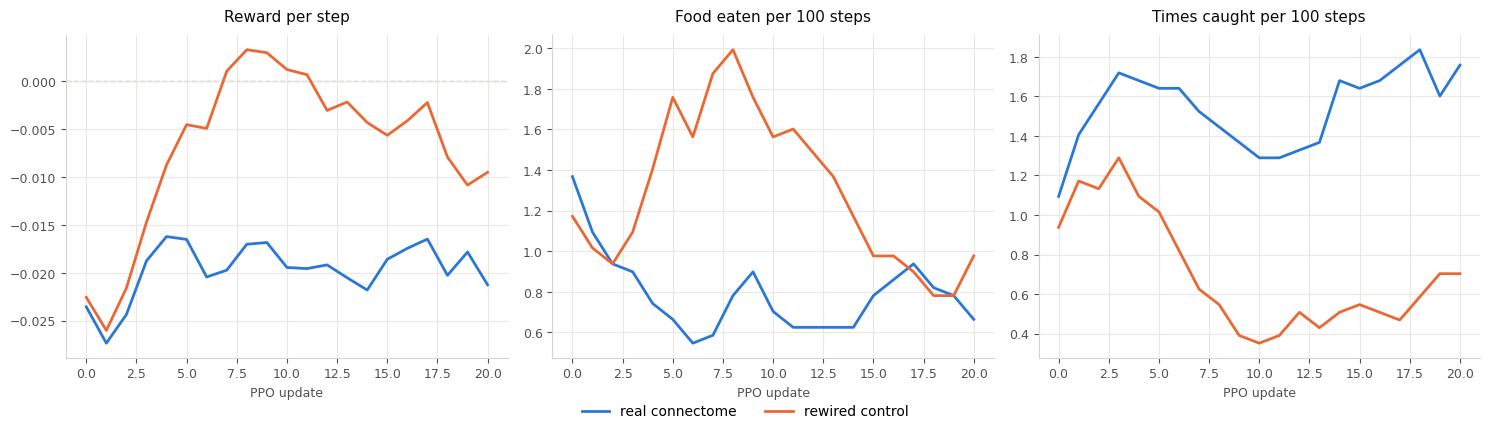

                    reward/step   food/100  caught/100
real connectome         -0.0199       0.72        1.70
rewired control         -0.0076       0.98        0.62


In [32]:
BLUE, ORANGE, RED, GRAY = "#2a78d6", "#eb6834", "#e34948", "#b8b6ae"

def style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#d6d4cc")
    ax.tick_params(colors="#52514e", labelsize=9)
    ax.grid(True, color="#e8e6df", linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    for s in ("xlabel", "ylabel", "title"):
        pass
    return ax

def smooth(v, k=5):
    v = np.asarray(v, dtype=float)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

metrics = [("reward_per_step", "Reward per step"),
           ("food_per_100", "Food eaten per 100 steps"),
           ("caught_per_100", "Times caught per 100 steps")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (key, title) in zip(axes, metrics):
    for hist, lab, col in [(hist_real, "real connectome", BLUE),
                           (hist_rw, "rewired control", ORANGE)]:
        y = smooth([h[key] for h in hist])
        ax.plot(np.arange(len(y)), y, color=col, linewidth=2, label=lab)
    style(ax)
    ax.set_title(title, fontsize=11, color="#0b0b0b", pad=10)
    ax.set_xlabel("PPO update", fontsize=9, color="#52514e")
axes[0].axhline(0, color=GRAY, linewidth=1, linestyle="--", zorder=0)
handles, labs = axes[0].get_legend_handles_labels()
fig.legend(handles, labs, frameon=False, fontsize=10, ncol=2,
           loc="lower center", bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "learning_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

def tail(hist, key, n=10):
    return float(np.mean([h[key] for h in hist[-n:]]))

print(f"{'':18s} {'reward/step':>12} {'food/100':>10} {'caught/100':>11}")
for hist, lab in [(hist_real, "real connectome"), (hist_rw, "rewired control")]:
    print(f"{lab:18s} {tail(hist,'reward_per_step'):+12.4f} "
          f"{tail(hist,'food_per_100'):10.2f} {tail(hist,'caught_per_100'):11.2f}")


## 13. Evaluate both, and record who was active when

Deterministic evaluation (no action noise) on unseen arenas. While evaluating the real
connectome we also record each neuron's average activity separately for **threat moments**
(the threat is close) and **foraging moments** (food is close and the threat is not), split
at the median so the two conditions are balanced.


In [33]:
@torch.no_grad()
def evaluate(policy, env, T=EVAL_STEPS, collect_activity=False):
    # pass 1: find what counts as "threat close" / "food close" for this run
    thr_v, odor_v = [], []
    if collect_activity:
        obs, h = env.reset(), policy.init_state(env.B)
        for _ in range(min(T, 100)):
            h, mean, _ = policy(h, obs)
            obs, _, info = env.step(mean)
            thr_v.append(info["threat_near"]); odor_v.append(info["odor"])
        thr_cut = torch.quantile(torch.cat(thr_v), 0.80).item()
        odor_cut = torch.quantile(torch.cat(odor_v), 0.70).item()

    obs, h = env.reset(), policy.init_state(env.B)
    tot = torch.zeros(env.B, device=policy.device)
    eaten = caught = 0.0
    a_thr = a_for = None
    n_t = n_f = 0
    for _ in range(T):
        h, mean, _ = policy(h, obs)
        obs, r, info = env.step(mean)
        tot += r
        eaten += info["n_eaten"].sum().item()
        caught += info["caught"].sum().item()
        if collect_activity:
            act = h.abs()
            tm = info["threat_near"] > thr_cut
            fm = (info["odor"] > odor_cut) & (~tm)
            if a_thr is None:
                a_thr = torch.zeros(policy.N, device=policy.device)
                a_for = torch.zeros(policy.N, device=policy.device)
            if tm.any():
                a_thr += act[tm].sum(0); n_t += int(tm.sum())
            if fm.any():
                a_for += act[fm].sum(0); n_f += int(fm.sum())

    out = {"return": tot.mean().item(), "food": eaten / env.B, "caught": caught / env.B}
    if collect_activity:
        out["act_threat"] = (a_thr / max(n_t, 1)).cpu().numpy()
        out["act_forage"] = (a_for / max(n_f, 1)).cpu().numpy()
        out["n_threat_frames"], out["n_forage_frames"] = n_t, n_f
    return out


eval_real = evaluate(policy_real, FlyEnv(batch=32, device=DEVICE, seed=99, **ENV_CFG),
                     collect_activity=True)
eval_rw = evaluate(policy_rw, FlyEnv(batch=32, device=DEVICE, seed=99, **ENV_CFG))

print(f"{'':22s} {'return':>9} {'food':>8} {'caught':>8}")
rows = [("real connectome", eval_real), ("rewired control", eval_rw)]
rows += [(f"[ref] {k}", v) for k, v in REFERENCE.items()]
for lab, r in rows:
    print(f"{lab:22s} {r['return']:+9.2f} {r['food']:8.2f} {r['caught']:8.2f}")


                          return     food   caught
real connectome            -1.34     1.22     1.72
rewired control            +0.39     2.56     0.94
[ref] random               -7.77     1.50     2.03
[ref] chemotaxis           +7.22    11.19     1.69
[ref] chemotaxis+avoid     +2.50     6.59     0.50


## 13b. Watch it move — a real trained episode, animated

One full episode of the trained, deterministic policy (no exploration noise), both networks
side by side, same arena, same seed. Left: real connectome. Right: rewired control.
Arrow = the fly. Green dots = food. Red circle = the threat's danger zone.
Saved to `results/fly_behavior.gif`.

recorded 250-step episodes | real: 0 eaten, 3 caught | rewired: 3 eaten, 0 caught
saved animation to results/fly_behavior.gif


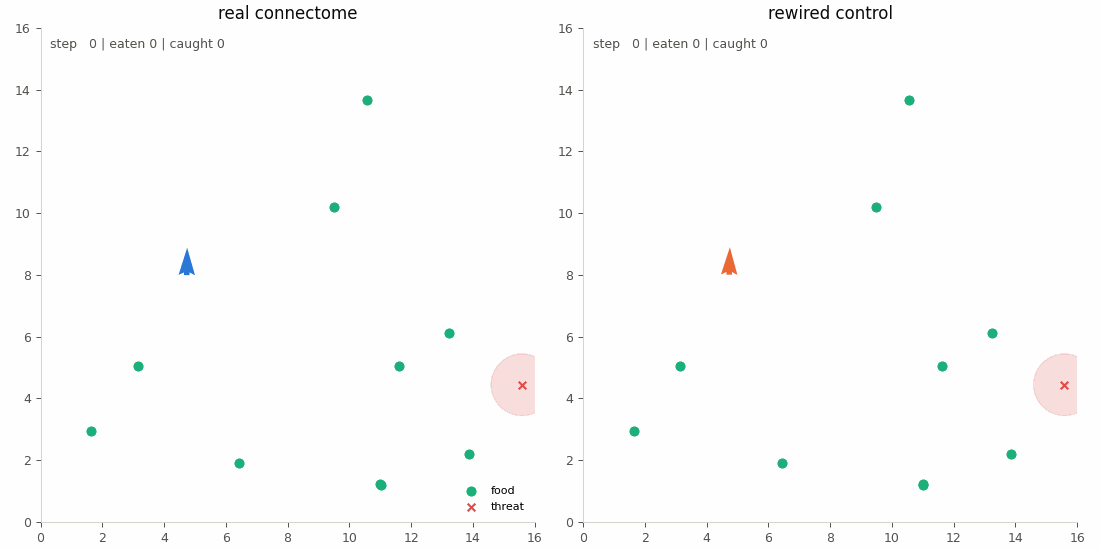

In [34]:
ensure("Pillow", "PIL")
import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import Image

FOOD_COLOR = "#1baf7a"


@torch.no_grad()
def record_episode(policy, env_cfg, T=250, seed=123):
    env = FlyEnv(batch=1, device=DEVICE, seed=seed, **env_cfg)
    obs = env.reset()
    h = policy.init_state(1)
    frames = []
    eaten_total = caught_total = 0
    for _ in range(T):
        h, mean, _ = policy(h, obs)
        obs, r, info = env.step(mean)
        eaten_total += int(info["n_eaten"].item() > 0)
        caught_total += int(info["caught"].item() > 0)
        frames.append({
            "pos": env.pos[0].cpu().numpy().copy(),
            "heading": float(env.heading[0]),
            "food": env.food[0].cpu().numpy().copy(),
            "threat": env.threat[0].cpu().numpy().copy(),
            "eaten_total": eaten_total,
            "caught_total": caught_total,
        })
    return frames


EP_T, EP_SEED = 250, 123
frames_real = record_episode(policy_real, ENV_CFG, T=EP_T, seed=EP_SEED)
frames_rw = record_episode(policy_rw, ENV_CFG, T=EP_T, seed=EP_SEED)
print(f"recorded {EP_T}-step episodes | "
      f"real: {frames_real[-1]['eaten_total']} eaten, {frames_real[-1]['caught_total']} caught | "
      f"rewired: {frames_rw[-1]['eaten_total']} eaten, {frames_rw[-1]['caught_total']} caught")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
panels = []
for ax, title, col in zip(axes, ["real connectome", "rewired control"], [BLUE, ORANGE]):
    ax.set_xlim(0, ENV_CFG["arena"]); ax.set_ylim(0, ENV_CFG["arena"])
    ax.set_aspect("equal")
    style(ax); ax.grid(False)
    ax.set_title(title, fontsize=12, color="#0b0b0b")
    trail, = ax.plot([], [], color=col, linewidth=1.2, alpha=0.5, zorder=2)
    agent_q = ax.quiver([0], [0], [1], [0], color=col, scale=18, width=0.012,
                        zorder=5, pivot="mid")
    food_sc = ax.scatter([], [], s=40, color=FOOD_COLOR, zorder=3, label="food")
    threat_zone = Circle((0, 0), ENV_CFG["catch_radius"], facecolor=RED, alpha=0.18,
                         edgecolor=RED, linewidth=1, zorder=1)
    ax.add_patch(threat_zone)
    threat_pt = ax.scatter([], [], s=30, color=RED, marker="x", zorder=4, label="threat")
    txt = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top", fontsize=9,
                  color="#52514e")
    panels.append(dict(trail=trail, agent=agent_q, food=food_sc,
                       threat_zone=threat_zone, threat_pt=threat_pt, txt=txt))
axes[0].legend(loc="lower right", frameon=False, fontsize=8)
plt.tight_layout()


def update(t):
    artists = []
    for panel, frames in zip(panels, [frames_real, frames_rw]):
        fr = frames[t]
        xs = [f["pos"][0] for f in frames[:t + 1]]
        ys = [f["pos"][1] for f in frames[:t + 1]]
        panel["trail"].set_data(xs, ys)
        panel["agent"].set_offsets([fr["pos"]])
        panel["agent"].set_UVC([np.cos(fr["heading"])], [np.sin(fr["heading"])])
        panel["food"].set_offsets(fr["food"])
        panel["threat_zone"].center = tuple(fr["threat"])
        panel["threat_pt"].set_offsets([fr["threat"]])
        panel["txt"].set_text(f"step {t:3d} | eaten {fr['eaten_total']} | caught {fr['caught_total']}")
        artists += [panel["trail"], panel["agent"], panel["food"],
                    panel["threat_zone"], panel["threat_pt"], panel["txt"]]
    return artists


anim = animation.FuncAnimation(fig, update, frames=EP_T, interval=50, blit=False)
gif_path = os.path.join(OUT_DIR, "fly_behavior.gif")
anim.save(gif_path, writer=animation.PillowWriter(fps=18))
plt.close(fig)
print("saved animation to", gif_path)

Image(filename=gif_path)

## 14. Result 2 — functional specialisation

For each neuropil, how much more active were its neurons during threat moments than during
foraging moments? Nothing in training ever told the network what any of these regions is for,
so any structure here came out of the wiring plus the task.

Red = more active under threat. Blue = more active while foraging.


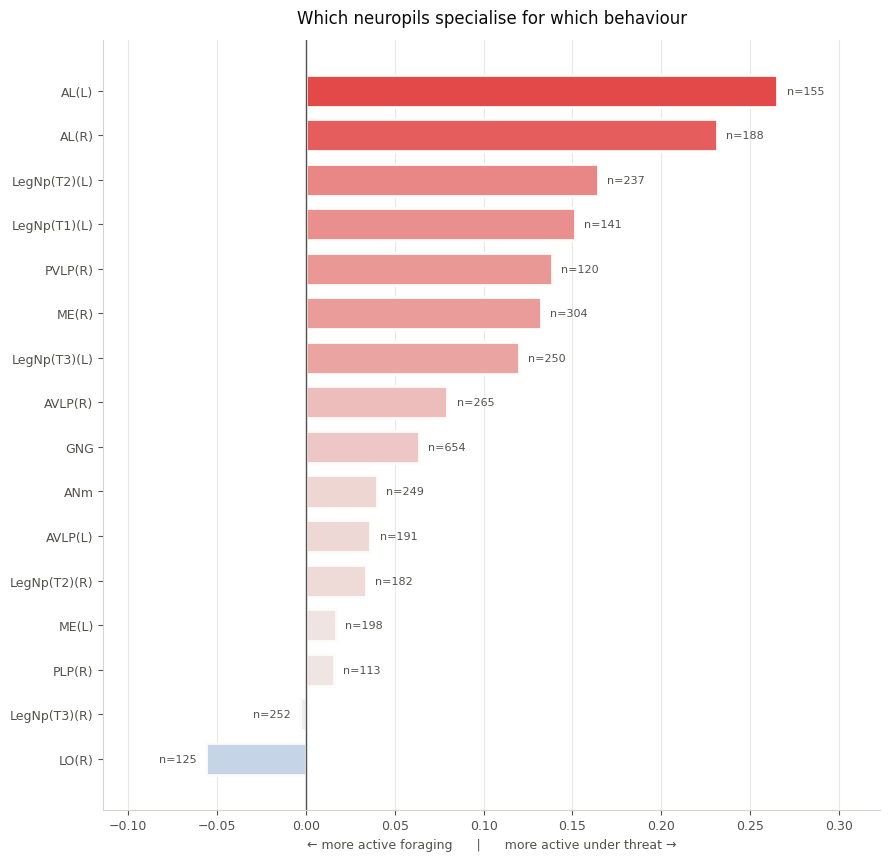

activity sampled from 1197 threat frames and 1001 foraging frames
neurons ever active during evaluation: 99.6% (5,976 of 6,000)


,neuropil,n_neurons,selectivity,mean_activity
13,LO(R),125,-0.056129,0.031443
3,LegNp(T3)(R),252,-0.003437,0.050062
15,PLP(R),113,0.015633,0.050002
7,ME(L),198,0.016847,0.026107
10,LegNp(T2)(R),182,0.033825,0.040055
8,AVLP(L),191,0.036314,0.020088
5,ANm,249,0.039876,0.045969
0,GNG,654,0.063582,0.050200
2,AVLP(R),265,0.079579,0.024213
4,LegNp(T3)(L),250,0.119746,0.034819


In [35]:
from matplotlib.colors import LinearSegmentedColormap

at, af = eval_real["act_threat"], eval_real["act_forage"]
sel = (at - af) / (at + af + 1e-8)          # -1 = purely foraging, +1 = purely threat

labels, counts = np.unique(graph.neuropil, return_counts=True)
keep = [(l, c) for l, c in zip(labels, counts) if c >= 10 and l != "unknown"]
keep = sorted(keep, key=lambda x: -x[1])[:16]

rows = []
for lab, n in keep:
    idx = np.where(graph.neuropil == lab)[0]
    rows.append({"neuropil": lab, "n_neurons": int(n),
                 "selectivity": float(np.mean(sel[idx])),
                 "mean_activity": float(np.mean((at[idx] + af[idx]) / 2))})
sel_df = pd.DataFrame(rows).sort_values("selectivity")

cmap = LinearSegmentedColormap.from_list("bwr2", [BLUE, "#f0efec", RED])
vmax = max(abs(sel_df["selectivity"]).max(), 1e-6)
colors = [cmap(0.5 + 0.5 * v / vmax) for v in sel_df["selectivity"]]

fig, ax = plt.subplots(figsize=(9, 0.42 * len(sel_df) + 2))
ax.barh(sel_df["neuropil"], sel_df["selectivity"], color=colors,
        edgecolor="#fcfcfb", linewidth=2, height=0.72)
ax.axvline(0, color="#52514e", linewidth=1)
style(ax)
ax.grid(axis="y", visible=False)
ax.set_xlabel("← more active foraging      |      more active under threat →",
              fontsize=9, color="#52514e")
ax.set_title("Which neuropils specialise for which behaviour", fontsize=12,
             color="#0b0b0b", pad=12)
for y, (v, n) in enumerate(zip(sel_df["selectivity"], sel_df["n_neurons"])):
    ax.text(v + (0.02 * vmax if v >= 0 else -0.02 * vmax), y, f"n={n}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8, color="#52514e")
ax.margins(x=0.18)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "neuropil_selectivity.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"activity sampled from {eval_real['n_threat_frames']} threat frames and "
      f"{eval_real['n_forage_frames']} foraging frames")

# How much of the connectome is actually doing anything? A neuron with no path from the
# sensory neurons stays at exactly zero forever, so this is worth knowing before you claim
# anything about "the full connectome".
FRAC_ACTIVE = float(np.mean((at + af) > 1e-6))
print(f"neurons ever active during evaluation: {FRAC_ACTIVE*100:.1f}% "
      f"({int(FRAC_ACTIVE*graph.n_nodes):,} of {graph.n_nodes:,})")
if FRAC_ACTIVE < 0.5:
    print("  -> most of the network is inert for this task. Expected to some degree: the task "
          "only drives a few sensory channels. Raising TICKS lets signal spread further per step.")
sel_df


## 15. Result 3 — virtual lesions

Silence one neuropil at a time and re-measure performance. Each is paired with a control that
silences the *same number* of randomly chosen neurons, so what you're reading is the effect of
losing **that region specifically**, not just the effect of losing that many neurons.

A bar to the right means the region mattered more than its size alone would predict.


In [36]:
def lesion_study(policy, env_cfg, graph, T=None, min_size=10, top_k=14, seed=0):
    T = T or max(80, EVAL_STEPS // 2)
    rng = np.random.default_rng(seed)
    mk = lambda s: FlyEnv(batch=16, device=DEVICE, seed=s, **env_cfg)
    intact = evaluate(policy, mk(7), T=T)["return"]

    labels, counts = np.unique(graph.neuropil, return_counts=True)
    order = [i for i in np.argsort(-counts)
             if counts[i] >= min_size and labels[i] != "unknown"][:top_k]
    rows = []
    for j, i in enumerate(order):
        lab, size = str(labels[i]), int(counts[i])
        idx = np.where(graph.neuropil == lab)[0]

        policy.lesion_mask.fill_(1.0)
        policy.lesion_mask[torch.as_tensor(idx, device=policy.device)] = 0.0
        les = evaluate(policy, mk(7), T=T)["return"]

        ridx = rng.choice(graph.n_nodes, size=size, replace=False)
        policy.lesion_mask.fill_(1.0)
        policy.lesion_mask[torch.as_tensor(ridx, device=policy.device)] = 0.0
        rnd = evaluate(policy, mk(7), T=T)["return"]

        policy.lesion_mask.fill_(1.0)
        rows.append({"neuropil": lab, "n_neurons": size, "intact": intact,
                     "lesioned": les, "random_control": rnd,
                     "drop": intact - les,
                     "excess_drop": (intact - les) - (intact - rnd)})
        print(f"  [{j+1}/{len(order)}] {lab:12s} n={size:5d}  drop {intact-les:+7.2f}  "
              f"vs random {(intact-les)-(intact-rnd):+7.2f}")
    policy.lesion_mask.fill_(1.0)
    return pd.DataFrame(rows)


print("running virtual lesions on the real connectome ...")
lesion_df = lesion_study(policy_real, ENV_CFG, graph)
lesion_df = lesion_df.sort_values("excess_drop")


running virtual lesions on the real connectome ...
  [1/14] GNG          n=  654  drop   -0.04  vs random   +0.64
  [2/14] ME(R)        n=  304  drop   -0.07  vs random   +0.22
  [3/14] AVLP(R)      n=  265  drop   -0.11  vs random   -0.03
  [4/14] LegNp(T3)(R) n=  252  drop   -0.05  vs random   +0.39
  [5/14] LegNp(T3)(L) n=  250  drop   -0.04  vs random   +0.17
  [6/14] ANm          n=  249  drop   -0.09  vs random   -0.04
  [7/14] LegNp(T2)(L) n=  237  drop   -0.01  vs random   +0.21
  [8/14] ME(L)        n=  198  drop   -0.08  vs random   -0.01
  [9/14] AVLP(L)      n=  191  drop   -0.05  vs random   +0.03
  [10/14] AL(R)        n=  188  drop   +0.06  vs random   +0.14
  [11/14] LegNp(T2)(R) n=  182  drop   +0.14  vs random   +0.00
  [12/14] AL(L)        n=  155  drop   -0.22  vs random   -0.15
  [13/14] LegNp(T1)(L) n=  141  drop   +0.53  vs random   +0.49
  [14/14] LO(R)        n=  125  drop   -0.05  vs random   +0.01


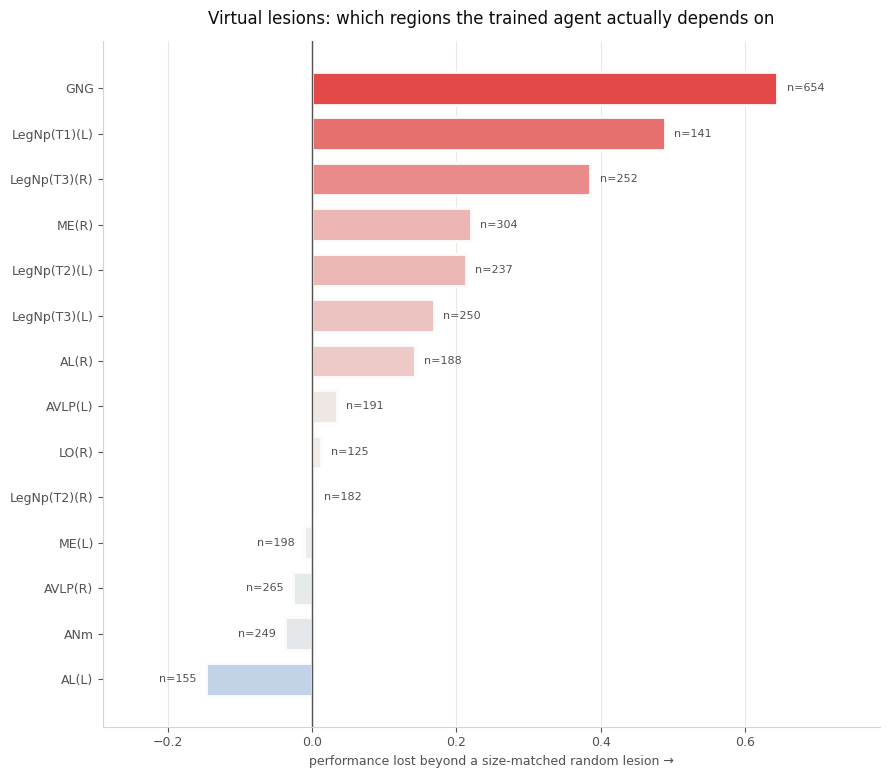

,neuropil,n_neurons,intact,lesioned,random_control,drop,excess_drop
11,AL(L),155,-0.604596,-0.381098,-0.527633,-0.223498,-0.146535
5,ANm,249,-0.604596,-0.511923,-0.548971,-0.092673,-0.037048
2,AVLP(R),265,-0.604596,-0.493344,-0.519385,-0.111252,-0.026041
7,ME(L),198,-0.604596,-0.529494,-0.540704,-0.075102,-0.011210
10,LegNp(T2)(R),182,-0.604596,-0.744845,-0.740911,0.140249,0.003934
13,LO(R),125,-0.604596,-0.557670,-0.544863,-0.046926,0.012808
8,AVLP(L),191,-0.604596,-0.557568,-0.522977,-0.047028,0.034591
9,AL(R),188,-0.604596,-0.663479,-0.520720,0.058883,0.142759
4,LegNp(T3)(L),250,-0.604596,-0.561477,-0.392655,-0.043119,0.168822
6,LegNp(T2)(L),237,-0.604596,-0.592766,-0.379984,-0.011831,0.212782


In [37]:
vmax = max(abs(lesion_df["excess_drop"]).max(), 1e-6)
colors = [cmap(0.5 + 0.5 * v / vmax) for v in lesion_df["excess_drop"]]

fig, ax = plt.subplots(figsize=(9, 0.42 * len(lesion_df) + 2))
ax.barh(lesion_df["neuropil"], lesion_df["excess_drop"], color=colors,
        edgecolor="#fcfcfb", linewidth=2, height=0.72)
ax.axvline(0, color="#52514e", linewidth=1)
style(ax)
ax.grid(axis="y", visible=False)
ax.set_xlabel("performance lost beyond a size-matched random lesion →",
              fontsize=9, color="#52514e")
ax.set_title("Virtual lesions: which regions the trained agent actually depends on",
             fontsize=12, color="#0b0b0b", pad=12)
for y, (v, n) in enumerate(zip(lesion_df["excess_drop"], lesion_df["n_neurons"])):
    ax.text(v + (0.02 * vmax if v >= 0 else -0.02 * vmax), y, f"n={n}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8, color="#52514e")
ax.margins(x=0.18)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "lesion_study.png"), dpi=150, bbox_inches="tight")
plt.show()
lesion_df


## 16. Result 4 — how far did RL move from biology?

Every synapse started at gain 1.0, meaning "exactly the strength the connectome says". This is
the distribution after training. A tight peak at 1.0 means the biological weights were already
close to useful; a wide spread means RL had to substantially rewrite them.


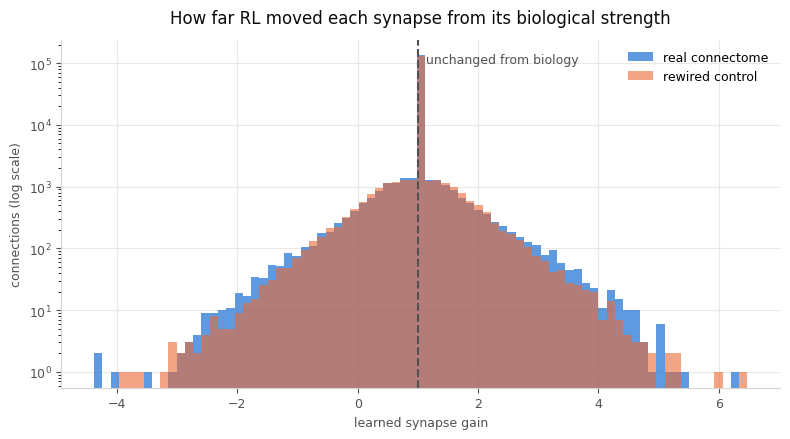

  real     mean 1.0016 | std 0.3219 | |change| median 0.0000 / p90 0.1754 / p99 1.6477 | fraction moved >10%: 0.1097
  rewired  mean 1.0004 | std 0.3011 | |change| median 0.0000 / p90 0.1883 / p99 1.4944 | fraction moved >10%: 0.1105


In [38]:
g_real = policy_real.w_gain.detach().cpu().numpy()
g_rw = policy_rw.w_gain.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(min(g_real.min(), g_rw.min()), max(g_real.max(), g_rw.max()), 80)
ax.hist(g_real, bins=bins, color=BLUE, alpha=0.75, label="real connectome")
ax.hist(g_rw, bins=bins, color=ORANGE, alpha=0.6, label="rewired control")
ax.axvline(1.0, color="#52514e", linewidth=1.5, linestyle="--")
ax.set_yscale("log")   # most synapses barely move; log scale keeps the tails readable
ax.text(1.0, ax.get_ylim()[1] * 0.6, "  unchanged from biology",
        fontsize=9, color="#52514e", va="top")
style(ax)
ax.set_xlabel("learned synapse gain", fontsize=9, color="#52514e")
ax.set_ylabel("connections (log scale)", fontsize=9, color="#52514e")
ax.set_title("How far RL moved each synapse from its biological strength",
             fontsize=12, color="#0b0b0b", pad=12)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "synapse_gains.png"), dpi=150, bbox_inches="tight")
plt.show()

for lab, g in [("real", g_real), ("rewired", g_rw)]:
    q = np.percentile(np.abs(g - 1.0), [50, 90, 99])
    print(f"  {lab:8s} mean {g.mean():.4f} | std {g.std():.4f} | "
          f"|change| median {q[0]:.4f} / p90 {q[1]:.4f} / p99 {q[2]:.4f} | "
          f"fraction moved >10%: {np.mean(np.abs(g-1) > 0.1):.4f}")


## 17. Save everything

In [39]:
summary = {
    "config": {"dataset": DATASET, "smoke_test": SMOKE_TEST, "device": DEVICE,
               "min_synapses": MIN_SYNAPSES, "max_neurons": MAX_NEURONS,
               "max_edges": MAX_EDGES, "ticks": TICKS, "updates": UPDATES,
               "rollout_T": ROLLOUT_T, "batch_envs": BATCH_ENVS, "seed": SEED,
               "env": ENV_CFG},
    "graph": {"n_neurons": graph.n_nodes, "n_connections": graph.n_edges,
              "n_sensory": len(graph.sensory_idx), "n_descending": len(graph.dn_idx),
              "pct_inhibitory": float(100 * (graph.sign < 0).mean()),
              "n_neuropils": int(len(set(graph.neuropil.tolist())))},
    "reference_controllers": REFERENCE,
    "final_training": {
        "real": {k: tail(hist_real, k) for k in
                 ["reward_per_step", "food_per_100", "caught_per_100"]},
        "rewired": {k: tail(hist_rw, k) for k in
                    ["reward_per_step", "food_per_100", "caught_per_100"]}},
    "evaluation": {
        "real": {k: v for k, v in eval_real.items() if not isinstance(v, np.ndarray)},
        "rewired": eval_rw,
        "fraction_neurons_ever_active": FRAC_ACTIVE},
    "synapse_gains": {
        "real": {"mean": float(g_real.mean()), "std": float(g_real.std())},
        "rewired": {"mean": float(g_rw.mean()), "std": float(g_rw.std())}},
    "neuropil_selectivity": sel_df.to_dict("records"),
    "lesion_study": lesion_df.to_dict("records"),
}

with open(os.path.join(OUT_DIR, "results_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

torch.save(policy_real.state_dict(), os.path.join(OUT_DIR, "policy_real.pt"))
torch.save(policy_rw.state_dict(), os.path.join(OUT_DIR, "policy_rewired.pt"))
pd.DataFrame(hist_real).to_csv(os.path.join(OUT_DIR, "history_real.csv"), index=False)
pd.DataFrame(hist_rw).to_csv(os.path.join(OUT_DIR, "history_rewired.csv"), index=False)

print("saved to ./results/:")
for f in sorted(os.listdir(OUT_DIR)):
    print("   ", f)

d = eval_real["return"] - eval_rw["return"]
print(f"\nheadline: real connectome {eval_real['return']:+.2f} vs "
      f"rewired control {eval_rw['return']:+.2f}  (difference {d:+.2f})")
print("random-walk baseline for scale:", f"{REFERENCE['random']['return']:+.2f}")


saved to ./results/:
    fly_behavior.gif
    history_real.csv
    history_rewired.csv
    learning_curves.png
    lesion_study.png
    neuropil_selectivity.png
    policy_real.pt
    policy_rewired.pt
    results_summary.json
    synapse_gains.png

headline: real connectome -1.34 vs rewired control +0.39  (difference -1.73)
random-walk baseline for scale: -7.77


## What to bring back

Send me `results/results_summary.json` plus the four PNGs and we can read them together.

The things worth looking at first:

- **Real vs rewired.** If the difference is small, that's a real finding, not a failure — it
  says the connectome's *global* wiring pattern isn't what carries this task, and the
  interesting follow-up is why. If the real connectome is clearly ahead, that's the headline
  result and the lesion data explains it.
- **One run is one sample.** Before drawing any conclusion from a gap between real and rewired,
  re-run both with 3–5 different `SEED` values. Two curves from a single seed can differ by a
  lot for no reason at all.
- **The lesion chart** is the part to sanity-check against the literature — if a region the
  agent depends on is one that real fly studies also implicate in navigation or avoidance,
  that's worth writing up carefully.

If training stalls, check cell 9 first: if the hand-coded controller still beats a random
walker by a wide margin there, the task is fine and the problem is in the network or the
hyperparameters.
